# TensorFlow Lite INT8 Quantization Validation for TF-OD SSD MobileNet

## Overview

This notebook demonstrates:

1. Converting a TensorFlow Object Detection (TF-OD)
   SSD MobileNet model to fully quantized INT8
   TensorFlow Lite
2. Running inference with the quantized model
3. Comparing FP32 vs INT8 outputs
4. Measuring quantization drift
5. Visualizing detection:
 
The workflow uses:

- TensorFlow 2.x
- TF Object Detection API exports
- Full integer quantization
- Representative dataset calibration
- PhenoBench dataset samples

---

## Environment Setup

This notebook was developed with:
- Python 3.10
- TensorFlow 2.11
- CUDA-enabled GPU

On Kaggle:
- Enable "Pin to original environment"
- Enable GPU acceleration

In [1]:
!python -V

import os
import json
from pathlib import Path

import numpy as np
import tensorflow as tf

print("TensorFlow:", tf.__version__)

np.random.seed(42)
tf.random.set_seed(42)

Python 3.10.10


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


TensorFlow: 2.11.0


In [2]:
!pip install tflite-support

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 MB 16.9 MB/s eta 0:00:00


In [3]:
!pip install \
  --upgrade \
  --force-reinstall \
  --no-cache-dir \
  --no-deps \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-gifvwg61
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-gifvwg61
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit 78f1461b78e08d85e7e9daeae462a329f1f00c6a
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1790987 sha256=6cc5b21b3c991e200f4b7a82a847333cac16cd51ab8e9ae257d6754ef4cde53d
  Stored in directory: /tmp/pip-ephem-wheel-cache-5m8xlf2u/wheels/47/ca/b5/23e0d1c70f8dbe929aaa72754dafc87b1c07721c0795e427ff
Successfully built agri-vision-edge


# Dataset and Model Setup

In [4]:
from agri_vision_edge.third_party.phenobench import PhenoBench
from agri_vision_edge.data import (
    representative_dataset,
    process_sample,
)

## Dataset Paths

In [5]:
dataset_dir = Path(
    "/kaggle/input/datasets/freimutdiener/"
    "phenobench-tfrecord-dataset-for-tensorflow-od"
)

dataset_raw_dir = Path(
    "/kaggle/input/datasets/freimutdiener/"
    "phenobench-raw-dataset-v1-1-0/PhenoBench"
)

## Model Paths
Important distinction:
- `tflite_export/saved_model`
  - used for TFLite conversion
- `exported_model/saved_model`
  - used for FP32 inference

In [6]:
model_base_path = (
    "/kaggle/input/models/freimutdiener/"
    "ssd-mobilenet-v2-fpnlite-320x320-coco17-tpu-8/"
    "tensorflow2/phenobench-fp32/2/"
)

tflite_saved_model_dir = model_base_path + "tflite_export/saved_model"

fp32_saved_model_dir = model_base_path + "exported_model/saved_model"

## Representative Dataset Indices

In [7]:
with open(dataset_dir / "rep_dataset.json", "r") as f:
    rep_ds_indices = json.load(f)

## Load Dataset

In [8]:
train_dataset = PhenoBench(
    root=dataset_raw_dir,
    split="train",
    target_types=["semantics", "plant_instances"],
    ignore_partial=False,
)

# Convert Model to Fully Quantized INT8 TFLite

## Configure Converter

In [9]:
converter = tf.lite.TFLiteConverter.from_saved_model(
    tflite_saved_model_dir
)

# Enable default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for calibration
converter.representative_dataset = lambda: representative_dataset(
    dataset=train_dataset,
    indices=rep_ds_indices,
    num_samples=200,
)

# Force fully quantized INT8 ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# INT8 input/output tensors
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

## Convert Model

In [10]:
tflite_model = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved model_int8.tflite")

fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Saved model_int8.tflite


In [11]:
tflite_size_mb = (
    os.path.getsize("model_int8.tflite")
    / 1024**2
)

print(
    f"TFLite model size: "
    f"{tflite_size_mb:.2f} MB"
)

TFLite model size: 3.31 MB


# Load TFLite Interpreter

In [12]:
interpreter = tf.lite.Interpreter(
    model_path="model_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Inspect Inputs and Outputs

In [13]:
from IPython.display import display

print("INPUTS:")
for detail in input_details:
    display(detail)

print("\nOUTPUTS:")
for detail in output_details:
    display(detail)

INPUTS:


{'name': 'serving_default_input:0',
 'index': 0,
 'shape': array([  1, 320, 320,   3], dtype=int32),
 'shape_signature': array([  1, 320, 320,   3], dtype=int32),
 'dtype': numpy.int8,
 'quantization': (1.0, -128),
 'quantization_parameters': {'scales': array([1.], dtype=float32),
  'zero_points': array([-128], dtype=int32),
  'quantized_dimension': 0},
 'sparsity_parameters': {}}


OUTPUTS:


{'name': 'StatefulPartitionedCall:1',
 'index': 386,
 'shape': array([  1, 100], dtype=int32),
 'shape_signature': array([  1, 100], dtype=int32),
 'dtype': numpy.int8,
 'quantization': (0.003233197145164013, -128),
 'quantization_parameters': {'scales': array([0.0032332], dtype=float32),
  'zero_points': array([-128], dtype=int32),
  'quantized_dimension': 0},
 'sparsity_parameters': {}}

{'name': 'StatefulPartitionedCall:3',
 'index': 384,
 'shape': array([  1, 100,   4], dtype=int32),
 'shape_signature': array([  1, 100,   4], dtype=int32),
 'dtype': numpy.int8,
 'quantization': (0.007785252295434475, -74),
 'quantization_parameters': {'scales': array([0.00778525], dtype=float32),
  'zero_points': array([-74], dtype=int32),
  'quantized_dimension': 0},
 'sparsity_parameters': {}}

{'name': 'StatefulPartitionedCall:0',
 'index': 387,
 'shape': array([1], dtype=int32),
 'shape_signature': array([1], dtype=int32),
 'dtype': numpy.int8,
 'quantization': (0.3921568691730499, -128),
 'quantization_parameters': {'scales': array([0.39215687], dtype=float32),
  'zero_points': array([-128], dtype=int32),
  'quantized_dimension': 0},
 'sparsity_parameters': {}}

{'name': 'StatefulPartitionedCall:2',
 'index': 385,
 'shape': array([  1, 100], dtype=int32),
 'shape_signature': array([  1, 100], dtype=int32),
 'dtype': numpy.int8,
 'quantization': (0.003921568859368563, -128),
 'quantization_parameters': {'scales': array([0.00392157], dtype=float32),
  'zero_points': array([-128], dtype=int32),
  'quantized_dimension': 0},
 'sparsity_parameters': {}}

## Verify Quantized Tensors

In [14]:
tensor_details = interpreter.get_tensor_details()

int8_tensors = sum(
    tensor["dtype"] == tf.int8
    for tensor in tensor_details
)

print("INT8 tensors:", int8_tensors)
print("Total tensors:", len(tensor_details))

INT8 tensors: 253
Total tensors: 391


# Prepare Sample Input

In [15]:
sample = train_dataset[0]

image = np.array(
    sample["image"],
    dtype=np.uint8,
)

image_resized, _, _ = process_sample(
    image=image,
    instances=sample["plant_instances"],
    semantics=sample["semantics"],
    size=320,
)

# Quantize Input

TensorFlow Lite uses affine quantization:

q = x / scale + zero_point

In [16]:
input_detail = input_details[0]

input_scale, input_zero_point = (
    input_detail["quantization"]
)

print("Scale:", input_scale)
print("Zero point:", input_zero_point)

Scale: 1.0
Zero point: -128


In [17]:
input_data = image_resized.astype(np.float32)

input_data = (
    input_data / input_scale
    + input_zero_point
)

input_data = np.round(input_data)

input_data = np.clip(
    input_data,
    -128,
    127,
).astype(np.int8)

input_data = np.expand_dims(
    input_data,
    axis=0,
)

# Run INT8 TFLite Inference

In [18]:
interpreter.set_tensor(
    input_detail["index"],
    input_data,
)

interpreter.invoke()

## Collect Raw Outputs

In [19]:
raw_outputs = []

for detail in output_details:

    tensor = interpreter.get_tensor(
        detail["index"]
    )

    raw_outputs.append(tensor)

    print(detail["name"])
    print(tensor.shape)

StatefulPartitionedCall:1
(1, 100)
StatefulPartitionedCall:3
(1, 100, 4)
StatefulPartitionedCall:0
(1,)
StatefulPartitionedCall:2
(1, 100)


# Dequantize Outputs

In [20]:
tflite_outputs = {}

for output, detail in zip(
    raw_outputs,
    output_details,
):

    scale, zero_point = detail["quantization"]

    output_float = scale * (
        output.astype(np.float32)
        - zero_point
    )

    tflite_outputs[detail["name"]] = output_float

## Inspect Output Tensors

In [21]:
for detail, output in zip(
    output_details,
    raw_outputs,
):

    scale, zero_point = (
        detail["quantization"]
    )

    dequantized = scale * (
        output.astype(np.float32)
        - zero_point
    )

    print(detail["name"])
    print("shape:", output.shape)
    print("dtype:", output.dtype)
    print("scale:", scale)
    print("zero_point:", zero_point)

    print("\nraw:")
    print(output.flatten()[:20])

    print("\ndequantized:")
    print(dequantized.flatten()[:20])

    print("\n" + "-" * 60 + "\n")

StatefulPartitionedCall:1
shape: (1, 100)
dtype: int8
scale: 0.003233197145164013
zero_point: -128

raw:
[ 42  15 -47 -64 -64 -68 -70 -70 -71 -74 -76 -77 -80 -83 -85 -85 -86 -86
 -87 -87]

dequantized:
[0.5496435  0.46234718 0.26188898 0.20692462 0.20692462 0.19399182
 0.18752544 0.18752544 0.18429224 0.17459264 0.16812626 0.16489306
 0.15519346 0.14549387 0.13902748 0.13902748 0.13579428 0.13579428
 0.13256109 0.13256109]

------------------------------------------------------------

StatefulPartitionedCall:3
shape: (1, 100, 4)
dtype: int8
scale: 0.007785252295434475
zero_point: -74

raw:
[-47 -30 -18 -17 -19 -32  19 -10 -45 -29 -20 -10  53 -19  55 -16 -63 -93
  84  71]

dequantized:
[ 0.21020181  0.3425511   0.43597412  0.44375938  0.4281889   0.3269806
  0.72402847  0.49825615  0.22577232  0.35033634  0.42040363  0.49825615
  0.98872703  0.4281889   1.0042975   0.45154464  0.08563778 -0.14791979
  1.2300699   1.1288615 ]

------------------------------------------------------------


# FP32 Reference Inference

The TFLite export SavedModel is NOT suitable
for standard eager inference.

Use:

- `exported_model/saved_model`
  for FP32 inference

- `tflite_export/saved_model`
  for TFLite conversion

In [22]:
detect_fn = tf.saved_model.load(
    fp32_saved_model_dir
)

infer = detect_fn.signatures[
    "serving_default"
]

## Inspect Signature

In [23]:
print(
    infer.structured_input_signature
)

print(
    infer.structured_outputs
)

((), {'input_tensor': TensorSpec(shape=(1, None, None, 3), dtype=tf.uint8, name='input_tensor')})
{'detection_classes': TensorSpec(shape=(1, 100), dtype=tf.float32, name='detection_classes'), 'num_detections': TensorSpec(shape=(1,), dtype=tf.float32, name='num_detections'), 'detection_scores': TensorSpec(shape=(1, 100), dtype=tf.float32, name='detection_scores'), 'detection_boxes': TensorSpec(shape=(1, 100, 4), dtype=tf.float32, name='detection_boxes'), 'raw_detection_boxes': TensorSpec(shape=(1, 12804, 4), dtype=tf.float32, name='raw_detection_boxes'), 'detection_multiclass_scores': TensorSpec(shape=(1, 100, 3), dtype=tf.float32, name='detection_multiclass_scores'), 'raw_detection_scores': TensorSpec(shape=(1, 12804, 3), dtype=tf.float32, name='raw_detection_scores'), 'detection_anchor_indices': TensorSpec(shape=(1, 100), dtype=tf.float32, name='detection_anchor_indices')}


## Run FP32 Inference

In [24]:
fp32_input = np.expand_dims(
    image_resized.astype(np.uint8),
    axis=0,
)

fp32_detections = infer(
    input_tensor=tf.convert_to_tensor(
        fp32_input
    )
)

## Inspect Outputs

In [25]:
for name, tensor in fp32_detections.items():

    array = tensor.numpy()

    print(name)
    print(array.shape)
    print(array.flatten()[:5])

    print()

detection_classes
(1, 100)
[1. 1. 1. 1. 1.]

num_detections
(1,)
[100.]

detection_scores
(1, 100)
[0.85625887 0.68010336 0.30966184 0.29531604 0.25054696]

detection_boxes
(1, 100, 4)
[0.246852   0.346574   0.4190545  0.43251407 0.47772217]

raw_detection_boxes
(1, 12804, 4)
[ 0.00513743  0.00392006  0.04404946  0.04643589 -0.03855713]

detection_multiclass_scores
(1, 100, 3)
[0.00455468 0.85625887 0.17399532 0.01874395 0.68010336]

raw_detection_scores
(1, 12804, 3)
[0.01640516 0.02514995 0.0222816  0.00826989 0.02355146]

detection_anchor_indices
(1, 100)
[ 3215. 10968.  3592.  1738.   334.]



# Map Detection Outputs

TFLite output ordering is model-export dependent.

Always inspect tensor ranges and shapes before
assuming output semantics.

Tensor ordering for this SSD TFLite export:

| Tensor | Meaning |
|---|---|
| StatefulPartitionedCall:0 | num detections |
| StatefulPartitionedCall:1 | scores |
| StatefulPartitionedCall:2 | classes |
| StatefulPartitionedCall:3 | boxes |

In [26]:
fp32_scores = fp32_detections[
    "detection_scores"
].numpy()

fp32_boxes = fp32_detections[
    "detection_boxes"
].numpy()

fp32_classes = fp32_detections[
    "detection_classes"
].numpy()

In [27]:
tflite_scores = tflite_outputs[
    "StatefulPartitionedCall:1"
]

tflite_classes = tflite_outputs[
    "StatefulPartitionedCall:2"
]

tflite_boxes = tflite_outputs[
    "StatefulPartitionedCall:3"
]

# Compare FP32 vs INT8 Scores

In [28]:
print("FP32 scores:")
print(fp32_scores[0][:10])

print("\nINT8 scores:")
print(tflite_scores[0][:10])

FP32 scores:
[0.85625887 0.68010336 0.30966184 0.29531604 0.25054696 0.24720532
 0.24155697 0.2312892  0.22691508 0.22045489]

INT8 scores:
[0.5496435  0.46234718 0.26188898 0.20692462 0.20692462 0.19399182
 0.18752544 0.18752544 0.18429224 0.17459264]


## Quantization Error

In [29]:
score_diff = np.abs(
    fp32_scores - tflite_scores
)

print(
    "Mean absolute difference:",
    score_diff.mean()
)

print(
    "Max absolute difference:",
    score_diff.max()
)

Mean absolute difference: 0.04879196
Max absolute difference: 0.30661535


In [30]:
class_match = (
    fp32_classes.astype(np.int32)
    == tflite_classes.astype(np.int32)
)

print(
    "Class agreement:",
    class_match.mean()
)

Class agreement: 0.22


# Visualize INT8 Detections

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

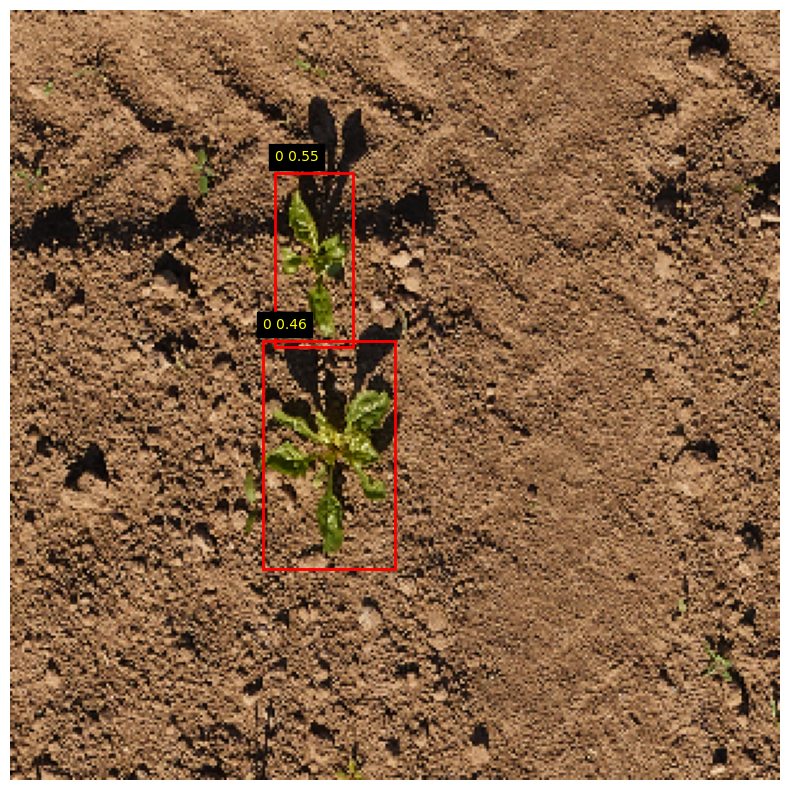

In [32]:
boxes = tflite_boxes[0]
scores = tflite_scores[0]
classes = tflite_classes[0]

fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.imshow(image_resized)

height, width = image_resized.shape[:2]

for box, score, cls in zip(
    boxes,
    scores,
    classes,
):

    if score < 0.3:
        continue

    ymin, xmin, ymax, xmax = box

    xmin *= width
    xmax *= width
    ymin *= height
    ymax *= height

    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin - 5,
        f"{int(cls)} {score:.2f}",
        color="yellow",
        backgroundcolor="black",
    )

plt.axis("off")
plt.show()

# Bounding Box Drift Analysis

## Intersection over Union (IoU)

In [33]:
def box_iou(box1, box2):
    """
    Compute IoU between two boxes.

    Box format:
    [ymin, xmin, ymax, xmax]
    """

    y1 = max(box1[0], box2[0])
    x1 = max(box1[1], box2[1])

    y2 = min(box1[2], box2[2])
    x2 = min(box1[3], box2[3])

    intersection = (
        max(0, y2 - y1)
        * max(0, x2 - x1)
    )

    area1 = (
        (box1[2] - box1[0])
        * (box1[3] - box1[1])
    )

    area2 = (
        (box2[2] - box2[0])
        * (box2[3] - box2[1])
    )

    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union

## Compute IoU Drift

In [34]:
ious = []

valid = fp32_scores[0] > 0.05

for fp32_box, int8_box in zip(
    fp32_boxes[0][valid],
    tflite_boxes[0][valid],
):

    ious.append(
        box_iou(
            fp32_box,
            int8_box,
        )
    )

ious = np.array(ious)

## Report Results

In [35]:
print("Mean IoU:", ious.mean())
print("Minimum IoU:", ious.min())

print("\nTop 10 IoUs:")
print(ious[:10])

Mean IoU: 0.03337832935154438
Minimum IoU: 0.0

Top 10 IoUs:
[0.64766216 0.74489808 0.         0.         0.         0.
 0.         0.         0.         0.        ]


In [36]:
if ious.mean() > 0.9:
    print(
        "Excellent localization preservation"
    )
elif ious.mean() > 0.75:
    print(
        "Acceptable localization drift"
    )
else:
    print(
        "Significant localization degradation"
    )

Significant localization degradation


# Summary

This notebook demonstrated:

- Full INT8 quantization of a TF-OD SSD MobileNet model
- Representative dataset calibration
- INT8 TFLite inference
- FP32 vs INT8 comparison
- Bounding box drift analysis
- Detection visualization

Typical healthy quantization results:

- Mean score difference:
  - < 0.05

- Mean IoU:
  - > 0.90

These indicate minimal accuracy degradation
after quantization.